In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Import necessary libraries and set the required parameters

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import os, io, json, base64, math, random, csv
from io import BytesIO
from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, models
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# torch.manual_seed(0)
# random.seed(0)
# np.random.seed(0)


In [2]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Image parameters
image_size = 32
channels = 3

# Training
batch_size = 128
# batch_size = 64
lr = 0.0002
beta1 = 0.5
# num_epochs = 50
# num_epochs = 10
# num_epochs = 3
latent_dim = 100
gen_features = 64
disc_features = 64
num_workers = 2


# Exploring the data folders and files

In [5]:
# WORK_DIR = '/kaggle/working'
# input_path = "/kaggle/input/test-gan-competition"
INPUT_ROOT = "/kaggle/input/test-gan-competition"   # folder that contains shard_00 ... shard_59 (all the folders containg jsonl file)
WORK_DIR = "/kaggle/working"

In [7]:
import os

root = "/kaggle/input/test-gan-competition"
print(os.listdir(root))

['shard_02', 'shard_45', 'shard_09', 'shard_37', 'shard_35', 'shard_15', 'shard_31', 'shard_50', 'shard_20', 'shard_25', 'shard_46', 'shard_39', 'shard_40', 'shard_44', 'shard_33', 'shard_59', 'shard_53', 'shard_54', 'shard_42', 'shard_41', 'shard_04', 'shard_07', 'shard_47', 'shard_18', 'shard_08', 'shard_03', 'shard_43', 'shard_55', 'shard_06', 'shard_12', 'shard_11', 'shard_51', 'shard_13', 'shard_38', 'shard_52', 'shard_17', 'shard_16', 'shard_26', 'shard_48', 'shard_00', 'shard_27', 'shard_24', 'shard_21', 'shard_57', 'shard_28', 'shard_32', 'shard_29', 'shard_10', 'shard_19', 'shard_49', 'shard_14', 'shard_23', 'shard_56', 'shard_30', 'shard_36', 'shard_05', 'shard_58', 'shard_01', 'shard_22', 'shard_34']


In [8]:
import os

input_path = "/kaggle/input/test-gan-competition"

shards = sorted(os.listdir(input_path))

total_lines = 0

for shard in shards:
    json_path = os.path.join(input_path, shard, "data.jsonl")
    print(json_path)
    with open(json_path, "r") as f:
        total_lines += sum(1 for _ in f)

print("Total JSONL lines:", total_lines)

/kaggle/input/test-gan-competition/shard_00/data.jsonl
/kaggle/input/test-gan-competition/shard_01/data.jsonl
/kaggle/input/test-gan-competition/shard_02/data.jsonl
/kaggle/input/test-gan-competition/shard_03/data.jsonl
/kaggle/input/test-gan-competition/shard_04/data.jsonl
/kaggle/input/test-gan-competition/shard_05/data.jsonl
/kaggle/input/test-gan-competition/shard_06/data.jsonl
/kaggle/input/test-gan-competition/shard_07/data.jsonl
/kaggle/input/test-gan-competition/shard_08/data.jsonl
/kaggle/input/test-gan-competition/shard_09/data.jsonl
/kaggle/input/test-gan-competition/shard_10/data.jsonl
/kaggle/input/test-gan-competition/shard_11/data.jsonl
/kaggle/input/test-gan-competition/shard_12/data.jsonl
/kaggle/input/test-gan-competition/shard_13/data.jsonl
/kaggle/input/test-gan-competition/shard_14/data.jsonl
/kaggle/input/test-gan-competition/shard_15/data.jsonl
/kaggle/input/test-gan-competition/shard_16/data.jsonl
/kaggle/input/test-gan-competition/shard_17/data.jsonl
/kaggle/in

# Data Decoding and Preprocessing

In [6]:
class ShardDataset(Dataset):
    #Loads all JSONL lines from shard subfolders under INPUT_ROOT.
    def __init__(self, root_dir, transform=None, verbose=True):
        self.root = root_dir
        self.transform = transform
        self.records = []

        entries = [] # list to collect jsonl files in all shards
        for entry in sorted(os.listdir(self.root)):
            shard_folder = os.path.join(self.root, entry)
            if(os.path.isdir(shard_folder)):
                for file_name in sorted(os.listdir(shard_folder)):
                    if(file_name.endswith(".jsonl")):
                        entries.append(os.path.join(shard_folder, file_name))
            # else:
            #     if(entry.endswith(".jsonl") or entry.endswith(".json")):
            #         entries.append(shard_folder)

        if(verbose):
            print("Found jsonl files:", len(entries))

        # load all images
        for jf in entries:
            with open(jf, "r") as fh: #open in read mode
                for line in fh:
                    line = line.strip()
                    if not line:
                        self.records.append(None)
                        continue
                    try:
                        rec = json.loads(line)
                        if isinstance(rec, dict) and 'root' in rec:
                            rec = rec['root']
                        if not ('img_b64' in rec or 'img64' in rec):
                            self.records.append(None)
                        else:
                            self.records.append(rec)
                    except Exception:
                        self.records.append(None)

        if(verbose):
            print(f"Loaded {len(self.records)} records (including invalid).")

        # default transform if not provided
        if self.transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((32,32), interpolation=Image.LANCZOS),
                transforms.ToTensor(),
                transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
            ])

    def __len__(self):
        return len(self.records)

    def _fallback_image(self):
        # mid-gray 32x32 RGB
        arr = np.full((32,32,3), 127, dtype=np.uint8)
        return Image.fromarray(arr)

    def _decode_image(self, rec):
        if rec is None:
            return self._fallback_image()

        b64 = rec.get("img_b64") or rec.get("img64")
        if not b64:
            return self._fallback_image()

        try:
            img_bytes = base64.b64decode(b64)
            img = Image.open(io.BytesIO(img_bytes))
        except Exception:
            return self._fallback_image()

        # convert 16-bit grayscale to 8-bit RGB
        mode = rec.get("mode", None)
        if mode == "I;16":
            try:
                arr16 = np.array(img, dtype=np.uint16)
                lo, hi = arr16.min(), arr16.max()
                if hi - lo < 1:
                    arr8 = np.full_like(arr16, 127, dtype=np.uint8)
                else:
                    # scale full range to 0-255
                    arr8 = ((arr16 - lo) / (hi - lo) * 255).astype(np.uint8)
                img = Image.fromarray(arr8).convert("RGB")
            except Exception:
                img = img.convert("RGB")
        else:
            try:
                img = img.convert('RGBA')
            except Exception:
                img = img.convert('RGB')

        # EXIF rotation
        exif_rot = rec.get('exif_rot', 0)
        if exif_rot in (90,180,270):
            try:
                img = img.rotate(-exif_rot, expand=True)
            except Exception:
                pass

        # alpha cropping
        alpha_b64 = rec.get('alpha_b64', None)
        if alpha_b64:
            try:
                a_bytes = base64.b64decode(alpha_b64)
                aimg = Image.open(io.BytesIO(a_bytes)).convert('L')
                bbox = aimg.getbbox()
                if bbox:
                    img = img.crop(bbox)
            except Exception:
                pass
        else:
            if img.mode == 'RGBA':
                try:
                    alpha = img.split()[-1]
                    bbox = alpha.getbbox()
                    if bbox:
                        img = img.crop(bbox)
                except Exception:
                    pass

        # flatten RGBA to RGB
        if img.mode == 'RGBA':
            try:
                bg = Image.new('RGB', img.size, (255,255,255))
                bg.paste(img, mask=img.split()[3])
                img = bg
            except Exception:
                img = img.convert('RGB')

        # inversion
        if rec.get('invert', False):
            try:
                img = ImageOps.invert(img.convert('RGB'))
            except Exception:
                pass

        # ensure 32x32
        try:
            img = img.resize((32,32), Image.LANCZOS)
        except Exception:
            img = self._fallback_image()

        return img

    def __getitem__(self, idx):
        rec = self.records[idx]
        pil_img = self._decode_image(rec)
        tensor = self.transform(pil_img)
        return tensor

# for visualisation

# def show_batch(dataset, n=16):
#     imgs = []
#     for i in range(n):
#         img = dataset[i]  # [-1,1]
#         # map to [0,1] for plotting
#         img = (img + 1) / 2
#         imgs.append(img)
#     batch = torch.stack(imgs)
#     grid = make_grid(batch, nrow=int(n**0.5), padding=2)
#     np_img = grid.permute(1,2,0).cpu().numpy()
#     plt.figure(figsize=(6,6))
#     plt.imshow(np_img)
#     plt.axis('off')
#     plt.show()


This class was also working fine.

In [11]:
# class ShardDataset(Dataset):
#     """
#     Loads all JSONL lines from shard subfolders under INPUT_ROOT.
#     Returns: tensor (3,32,32) normalized to [-1,1]
#     """
#     def __init__(self, root_dir, transform=None, verbose=True):
#         self.root = root_dir
#         self.transform = transform
#         self.records = []

#         entries = []
#         for entry in sorted(os.listdir(self.root)):
#             shard_folder = os.path.join(self.root, entry)
#             if os.path.isdir(shard_folder):
#                 for file_name in sorted(os.listdir(shard_folder)):
#                     if file_name.endswith(".jsonl") or file_name.endswith(".json"):
#                         entries.append(os.path.join(shard_folder, file_name))
#             else:
#                 if entry.endswith(".jsonl") or entry.endswith(".json"):
#                     entries.append(shard_folder)

#         if verbose:
#             print("Found jsonl files:", len(entries))

#         for jf in entries:
#             with open(jf, "r") as fh:
#                 for line in fh:
#                     line = line.strip()
#                     if not line:
#                         self.records.append(None)
#                         continue
#                     try:
#                         rec = json.loads(line)
#                         if isinstance(rec, dict) and "root" in rec:
#                             rec = rec["root"]
#                         if not ('img_b64' in rec or 'img64' in rec):
#                             self.records.append(None)
#                         else:
#                             self.records.append(rec)
#                     except:
#                         self.records.append(None)

#         if verbose:
#             print(f"Loaded {len(self.records)} records.")

#         if self.transform is None:
#             self.transform = transforms.Compose([
#                 transforms.Resize((32,32), interpolation=Image.LANCZOS),
#                 transforms.ToTensor(),
#                 transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
#             ])

#     def __len__(self):
#         return len(self.records)

#     def _fallback_image(self):
#         arr = np.full((32,32,3), 127, dtype=np.uint8)
#         return Image.fromarray(arr)

#     def _decode_image(self, rec):
#         if rec is None:
#             return self._fallback_image()
    
#         b64 = rec.get("img_b64") or rec.get("img64")
#         if b64 is None:
#             return self._fallback_image()
    
#         try:
#             img_bytes = base64.b64decode(b64)
#             img = Image.open(io.BytesIO(img_bytes))
#         except:
#             return self._fallback_image()
    
#         mode = rec.get("mode")
    
#         # if mode == "I;16":
#         #     try:
#         #         # Read 16-bit grayscale exactly
#         #         arr16 = np.array(img, dtype=np.uint16)
    
#         #         # Convert 16-bit → 8-bit for display/model
#         #         arr8 = (arr16 >> 8).astype(np.uint8)
    
#         #         # Remove 'mode' parameter (Pillow deprecation warning)
#         #         img = Image.fromarray(arr8).convert("RGB")
#         #     except:
#         #         img = img.convert("RGB")

#         #this worked fine ,.......
#         # if mode == "I;16":
#         #     try:
#         #         # Read 16-bit array
#         #         arr16 = np.array(img, dtype=np.uint16)
        
#         #         # Check min/max
#         #         lo, hi = arr16.min(), arr16.max()
#         #         if hi > lo:
#         #             # Normalize to [0,255] dynamically per image
#         #             arr8 = ((arr16 - lo) / (hi - lo) * 255).astype(np.uint8)
#         #         else:
#         #             # If all values same, fill mid-gray
#         #             arr8 = np.full_like(arr16, 127, dtype=np.uint8)
        
#         #         img = Image.fromarray(arr8).convert("RGB")
#         #     except:
#         #         img = img.convert("RGB")
#         if mode == "I;16":
#             try:
#                 arr16 = np.array(img, dtype=np.uint16)
#                 lo, hi = arr16.min(), arr16.max()
        
#                 # Handle tiny dynamic range
#                 if hi - lo < 1:   # basically uniform
#                     arr8 = np.full_like(arr16, 127, dtype=np.uint8)  # mid-gray
#                 else:
#                     # Clip outliers: 1st and 99th percentile
#                     lo_clip, hi_clip = np.percentile(arr16, 1), np.percentile(arr16, 99)
#                     arr16 = np.clip(arr16, lo_clip, hi_clip)
        
#                     # Scale to 0-255
#                     arr8 = ((arr16 - arr16.min()) / (arr16.max() - arr16.min()) * 255).astype(np.uint8)
        
#                 img = Image.fromarray(arr8).convert("RGB")
#             except Exception:
#                 img = img.convert("RGB")

#         else:
#             try:
#                 img = img.convert("RGBA")
#             except:
#                 img = img.convert("RGB")
    
#         # -------------------------------------------------
#         #   EXIF rotation correction
#         # -------------------------------------------------
#         rot = rec.get("exif_rot", 0)
#         if rot in (90,180,270):
#             try:
#                 img = img.rotate(-rot, expand=True)
#             except:
#                 pass
    
#         # -------------------------------------------------
#         #   Alpha mask cropping
#         # -------------------------------------------------
#         alpha_b64 = rec.get("alpha_b64")
#         if alpha_b64:
#             try:
#                 a_bytes = base64.b64decode(alpha_b64)
#                 aimg = Image.open(io.BytesIO(a_bytes)).convert('L')
#                 bbox = aimg.getbbox()
#                 if bbox:
#                     img = img.crop(bbox)
#             except:
#                 pass
#         else:
#             if img.mode == "RGBA":
#                 try:
#                     alpha = img.split()[-1]
#                     bbox = alpha.getbbox()
#                     if bbox:
#                         img = img.crop(bbox)
#                 except:
#                     pass
    
#         # -------------------------------------------------
#         #   Flatten RGBA to RGB on white background
#         # -------------------------------------------------
#         if img.mode == 'RGBA':
#             try:
#                 bg = Image.new('RGB', img.size, (255,255,255))
#                 bg.paste(img, mask=img.split()[3])
#                 img = bg
#             except:
#                 img = img.convert('RGB')
    
#         # -------------------------------------------------
#         #   Inversion
#         # -------------------------------------------------
#         if rec.get("invert", False):
#             try:
#                 img = ImageOps.invert(img)
#             except:
#                 pass
    
#         try:
#             img = img.convert("RGB")
#         except:
#             img = self._fallback_image()
    
#         # Ensure 32x32
#         try:
#             img = img.resize((32,32), Image.LANCZOS)
#         except:
#             img = self._fallback_image()
#         return img

#     def __getitem__(self, idx):
#         rec = self.records[idx]
#         pil_img = self._decode_image(rec)
#         tensor = self.transform(pil_img)
#         return tensor


In [7]:
transform_32 = transforms.Compose([
    transforms.Resize((32,32), interpolation=Image.LANCZOS),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [8]:
# dataset = GANShardDataset(input_path, transform)
# dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)
# print("Total images:", len(dataset))
dataset = ShardDataset(INPUT_ROOT, transform=None, verbose=True)
print("Dataset length:", len(dataset))
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

Found jsonl files: 60
Loaded 60000 records (including invalid).
Dataset length: 60000


In [10]:
dataset.records[0]


{'id': 'train-000000',
 'mode': 'I;16',
 'size': [32, 32],
 'exif_rot': 270,
 'invert': False,
 'label': 0,
 'img_b64': 'iVBORw0KGgoAAAANSUhE###',
 'alpha_b64': None}

# Data Visualization

In [15]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torch

%matplotlib inline

def show_batch(dataset, n=16):
    imgs = []
    for i in range(n):
        img = dataset[i]  # tensor (3,32,32) in [-1,1]
        imgs.append(img)

    batch = torch.stack(imgs)

    # Undo normalization for display
    mean = torch.tensor([0.5,0.5,0.5]).view(3,1,1)
    std  = torch.tensor([0.5,0.5,0.5]).view(3,1,1)
    batch = batch * std + mean  # back to [0,1]

    # Make grid
    grid = make_grid(batch, nrow=int(n**0.5), padding=2)

    # Convert to numpy
    np_img = grid.permute(1,2,0).cpu().numpy()
    np_img = np.clip(np_img, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(np_img)
    plt.axis("off")
    plt.show()

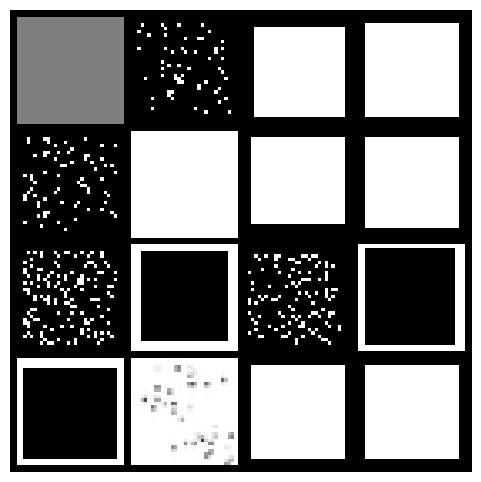

In [16]:
show_batch(dataset, n=16) 

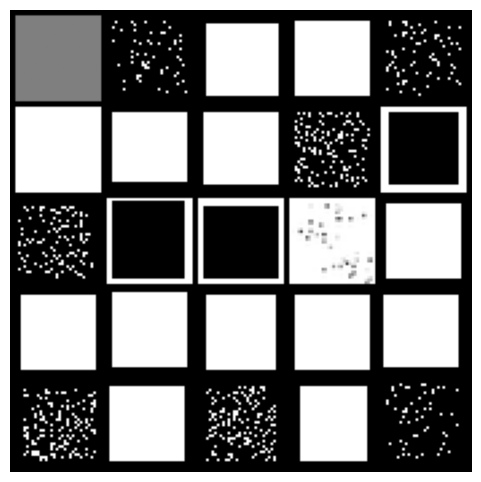

In [17]:

show_batch(dataset, n=25)


# Model Building

## DC GAN

In [18]:
# class Generator32(nn.Module):
#     def __init__(self, latent_dim=100, gen_features=64, channels=3):
#         super(Generator32, self).__init__()
#         self.main = nn.Sequential(
#             # input: Z latent vector (latent_dim x 1 x 1)
#             nn.ConvTranspose2d(latent_dim, gen_features*4, 4, 1, 0, bias=False),  # 4x4
#             nn.BatchNorm2d(gen_features*4),
#             nn.ReLU(True),

#             nn.ConvTranspose2d(gen_features*4, gen_features*2, 4, 2, 1, bias=False),  # 8x8
#             nn.BatchNorm2d(gen_features*2),
#             nn.ReLU(True),

#             nn.ConvTranspose2d(gen_features*2, gen_features, 4, 2, 1, bias=False),  # 16x16
#             nn.BatchNorm2d(gen_features),
#             nn.ReLU(True),

#             nn.ConvTranspose2d(gen_features, channels, 4, 2, 1, bias=False),  # 32x32
#             nn.Tanh()  # output in [-1,1]
#         )

#     def forward(self, x):
#         return self.main(x)

# class Discriminator32(nn.Module):
#     def __init__(self, channels=3, disc_features=64):
#         super(Discriminator32, self).__init__()
#         self.main = nn.Sequential(
#             # input: (channels) x 32 x 32
#             nn.Conv2d(channels, disc_features, 4, 2, 1, bias=False),  # 16x16
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(disc_features, disc_features*2, 4, 2, 1, bias=False),  # 8x8
#             nn.BatchNorm2d(disc_features*2),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(disc_features*2, disc_features*4, 4, 2, 1, bias=False),  # 4x4
#             nn.BatchNorm2d(disc_features*4),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(disc_features*4, 1, 4, 1, 0, bias=False),  # 1x1
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         return self.main(x).view(-1)




In [19]:
# class Generator(nn.Module):
#     def __init__(self, latent_dim, gen_features=64, channels=3):
#         super().__init__()
#         self.main = nn.Sequential(
#             nn.ConvTranspose2d(latent_dim, gen_features*8, 4, 1,0,bias=False),
#             nn.BatchNorm2d(gen_features*8),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(gen_features*8, gen_features*4, 4,2,1,bias=False),
#             nn.BatchNorm2d(gen_features*4),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(gen_features*4, gen_features*2, 4,2,1,bias=False),
#             nn.BatchNorm2d(gen_features*2),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(gen_features*2, gen_features, 4,2,1,bias=False),
#             nn.BatchNorm2d(gen_features),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(gen_features, channels, 3,1,1,bias=False),
#             nn.Tanh()
#         )
#     def forward(self,x):
#         return self.main(x)

# # Discriminator
# class Discriminator(nn.Module):
#     def __init__(self, channels=3, disc_features=64):
#         super().__init__()
#         self.main = nn.Sequential(
#             nn.Conv2d(channels, disc_features, 4,2,1,bias=False),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(disc_features, disc_features*2, 4,2,1,bias=False),
#             nn.BatchNorm2d(disc_features*2),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(disc_features*2, disc_features*4, 4,2,1,bias=False),
#             nn.BatchNorm2d(disc_features*4),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(disc_features*4, 1, 4,1,0,bias=False),
#             nn.Sigmoid()
#         )
#     def forward(self,x):
        # return self.main(x).view(-1)

In [20]:
# netG = Generator32(latent_dim, gen_features, channels).to(device)
# netD = Discriminator32(channels, disc_features).to(device)

# criterion = nn.BCELoss()
# optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
# optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)


In [21]:
# latent_dim = 100
# netG = Generator(latent_dim).to(device)
# netD = Discriminator().to(device)
# criterion = nn.BCELoss()
# optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5,0.999))
# optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5,0.999))

## Diffusion

In [22]:
# def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
#     return torch.linspace(beta_start, beta_end, T)

# T = 1000  # total diffusion steps
# betas = linear_beta_schedule(T).to(device)
# alphas = 1.0 - betas
# alphas_cumprod = torch.cumprod(alphas, dim=0)

# from math import pi

# def cosine_beta_schedule(T, s=0.008):
#     """
#     Cosine schedule for betas (from Nichol & Dhariwal, 2021)
#     Produces smoother noise and better sampling.
#     """
#     steps = T + 1
#     x = torch.linspace(0, T, steps)
#     alphas_cumprod = torch.cos(((x / T + s) / (1 + s)) * pi / 2) ** 2
#     alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
#     betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
#     return torch.clamp(betas, 0.0001, 0.9999)

# T = 1000  # total diffusion steps
# betas = cosine_beta_schedule(T).to(device)
# alphas = 1.0 - betas
# alphas_cumprod = torch.cumprod(alphas, dim=0)

# --- Simple U-Net for DDPM ---
# class SimpleUNet(nn.Module):
#     def __init__(self, channels=3):
#         super().__init__()
#         self.enc1 = nn.Conv2d(channels, 64, 3, padding=1)
#         self.enc2 = nn.Conv2d(64, 128, 3, padding=1)
#         self.dec1 = nn.ConvTranspose2d(128, 64, 3, padding=1)
#         self.dec2 = nn.ConvTranspose2d(64, channels, 3, padding=1)
#         self.act = nn.ReLU()
        
#     def forward(self, x, t):
#         # t can be used for timestep embedding (optional for simple model)
#         h = self.act(self.enc1(x))
#         h = self.act(self.enc2(h))
#         h = self.act(self.dec1(h))
#         return self.dec2(h)

# import torch
# import torch.nn as nn

# class ResidualBlock(nn.Module):
#     def __init__(self, channels):
#         super().__init__()
#         self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
#         self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
#         self.act = nn.ReLU()
    
#     def forward(self, x):
#         out = self.act(self.conv1(x))
#         out = self.conv2(out)
#         return self.act(out + x)

# class SimpleUNet(nn.Module):
#     def __init__(self, channels=3, num_res_blocks=2):
#         super().__init__()

#         # Encoder
#         self.enc1 = nn.Conv2d(channels, 64, 3, padding=1)
#         self.enc2 = nn.Conv2d(64, 128, 3, padding=1)

#         # Residual blocks for encoder
#         self.res_blocks_enc = nn.ModuleList([
#             ResidualBlock(128) for _ in range(num_res_blocks)
#         ])

#         # Decoder
#         self.dec1 = nn.ConvTranspose2d(128, 64, 3, padding=1)

#         # Residual blocks for decoder
#         self.res_blocks_dec = nn.ModuleList([
#             ResidualBlock(64) for _ in range(num_res_blocks)
#         ])

#         self.dec2 = nn.ConvTranspose2d(64, channels, 3, padding=1)
#         self.act = nn.ReLU()

#     def forward(self, x, t=None):
#         h = self.act(self.enc1(x))    # 3 -> 64
#         h = self.act(self.enc2(h))    # 64 -> 128

#         for block in self.res_blocks_enc:
#             h = block(h)

#         h = self.act(self.dec1(h))    # 128 -> 64

#         for block in self.res_blocks_dec:
#             h = block(h)

#         return self.dec2(h)           # 64 -> 3


# # model = SimpleUNet().to(device)
# model = SimpleUNet(num_res_blocks=2).to(device)

# optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

# # --- Forward diffusion sample ---
# def q_sample(x0, t, noise=None):
#     if noise is None:
#         noise = torch.randn_like(x0)
#     sqrt_alpha_cumprod = torch.sqrt(alphas_cumprod[t])[:, None, None, None]
#     sqrt_one_minus_alpha = torch.sqrt(1 - alphas_cumprod[t])[:, None, None, None]
#     return sqrt_alpha_cumprod * x0 + sqrt_one_minus_alpha * noise


## WGAN (WGAN-GP)

In [9]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, gen_features=64, channels=3):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, gen_features*8, 4, 1, 0, bias=False),   # 1×1 → 4×4
            nn.BatchNorm2d(gen_features*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(gen_features*8, gen_features*4, 4, 2, 1, bias=False),  # 4x4 → 8x8
            nn.BatchNorm2d(gen_features*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(gen_features*4, gen_features*2, 4, 2, 1, bias=False),  # 8x8 → 16x16
            nn.BatchNorm2d(gen_features*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(gen_features*2, gen_features, 4, 2, 1, bias=False),    # 16x16 → 32x32
            nn.BatchNorm2d(gen_features),
            nn.ReLU(True),

            nn.ConvTranspose2d(gen_features, channels, 3, 1, 1, bias=False),       # 32×32 → 32×32
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Critic(nn.Module):
    def __init__(self, channels=3, disc_features=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(channels, disc_features, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(disc_features, disc_features*2, 4, 2, 1),
            nn.InstanceNorm2d(disc_features*2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(disc_features*2, disc_features*4, 4, 2, 1),
            nn.InstanceNorm2d(disc_features*4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(disc_features*4, 1, 4, 1, 0),   # output is 1 number
        )

    def forward(self, x):
        return self.net(x).view(-1)

# class Critic(nn.Module):
#     def __init__(self, channels=3, disc_features=64):
#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Conv2d(channels, disc_features, 4, 2, 1),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(disc_features, disc_features * 2, 4, 2, 1),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(disc_features * 2, disc_features * 4, 4, 2, 1),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(disc_features * 4, 1, 4, 1, 0),
#         )

#     def forward(self, x):
#         return self.net(x).view(-1)



In [10]:
def gradient_penalty(critic, real, fake, device):
    batch = real.size(0)

    # random weight for interpolation
    eps = torch.rand(batch, 1, 1, 1).to(device)
    mix = eps * real + (1 - eps) * fake
    mix.requires_grad_(True)

    out = critic(mix)

    grad = torch.autograd.grad(
        out,
        mix,
        grad_outputs=torch.ones_like(out),
        create_graph=True,
        retain_graph=True
    )[0]

    grad = grad.view(batch, -1)
    gp = ((grad.norm(2, dim=1) - 1)**2).mean()
    # gp = torch.mean((grads.norm(2, dim=1) - 1)**2)
    return gp
# def gradient_penalty(critic, real, fake, device):
#     bs = real.size(0)
#     alpha = torch.rand(bs, 1, 1, 1, device=device)
#     interpolated = (real * alpha + fake * (1 - alpha)).requires_grad_(True)

#     pred = critic(interpolated)

#     grads = torch.autograd.grad(
#         outputs=pred,
#         inputs=interpolated,
#         grad_outputs=torch.ones_like(pred),
#         create_graph=True,
#         retain_graph=True,
#         only_inputs=True
#     )[0]

#     grads = grads.view(bs, -1)
#     gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
#     return gp




In [11]:
lr = 1e-4
lambda_gp = 10
critic_iters = 5
# critic_iters = 3
device = "cuda"

G = Generator().to(device)
D = Critic().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.9))

# lr = 1e-4
# lambda_gp = 10
# critic_iters = 2    
# device = "cuda"

# G = Generator().to(device)
# D = Critic().to(device)

# opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
# opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.0, 0.9))



# Traning loop

## For WGAN

In [12]:
epochs = 20

for ep in range(epochs):
    for batch in dataloader:
        real = batch.to(device)
        bs = real.size(0)

        # critic update
        for _ in range(critic_iters):
            noise = torch.randn(bs, 100, 1, 1).to(device)
            fake = G(noise)
            
            d_real = D(real)
            d_fake = D(fake.detach())
            gp = gradient_penalty(D, real, fake, device)

            d_loss = -(d_real.mean() - d_fake.mean()) + lambda_gp * gp

            opt_D.zero_grad()
            d_loss.backward()
            opt_D.step()

        # generator step
        noise = torch.randn(bs, 100, 1, 1).to(device)
        fake = G(noise)
        g_loss = -D(fake).mean()

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(f"Epoch {ep}: D={d_loss.item():.4f}, G={g_loss.item():.4f}")


Epoch 0: D=-17.7389, G=77.6457
Epoch 1: D=-17.9842, G=77.3292
Epoch 2: D=-14.3170, G=86.0878
Epoch 3: D=-11.1914, G=85.1335
Epoch 4: D=-11.5227, G=89.1790
Epoch 5: D=-11.8922, G=90.9937
Epoch 6: D=-13.1426, G=98.7485
Epoch 7: D=-9.5887, G=105.5551
Epoch 8: D=-11.5886, G=111.2398
Epoch 9: D=-6.8829, G=111.6365
Epoch 10: D=-9.5146, G=118.0372
Epoch 11: D=-10.2585, G=116.5707
Epoch 12: D=-15.4784, G=125.3759
Epoch 13: D=-7.2976, G=119.1346
Epoch 14: D=-6.7318, G=116.1849
Epoch 15: D=-9.0564, G=118.3237
Epoch 16: D=-10.7884, G=119.0684
Epoch 17: D=-7.9017, G=122.6875
Epoch 18: D=-8.7381, G=125.1615
Epoch 19: D=-7.2234, G=129.6855


In [ ]:
# epochs = 5

# for epoch in range(epochs):
#     for i, real_imgs in enumerate(dataloader):
#         real_imgs = real_imgs.to(device)

#         # ----------------------
#         # Train Critic
#         # ----------------------
#         for _ in range(critic_updates):

#             # Noise must be 4D: (B, 100, 1, 1)
#             z = torch.randn(real_imgs.size(0), latent_dim, 1, 1).to(device)

#             fake_imgs = G(z).detach()

#             real_scores = D(real_imgs)
#             fake_scores = D(fake_imgs)

#             loss_D = -(torch.mean(real_scores) - torch.mean(fake_scores))

#             optimizer_D.zero_grad()
#             loss_D.backward()
#             optimizer_D.step()

#             # Weight clipping for WGAN
#             for p in D.parameters():
#                 p.data.clamp_(-clip_value, clip_value)

#         # ----------------------
#         # Train Generator
#         # ----------------------
#         z = torch.randn(real_imgs.size(0), latent_dim, 1, 1).to(device)

#         fake_imgs = G(z)
#         loss_G = -torch.mean(D(fake_imgs))

#         optimizer_G.zero_grad()
#         loss_G.backward()
#         optimizer_G.step()

#     print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")


## For Diffusion

In [ ]:
# import os

# # Make sure directories exist
# os.makedirs("checkpoints", exist_ok=True)
# os.makedirs("samples", exist_ok=True)


In [ ]:
# from tqdm import tqdm
# import torch.nn.functional as F
# num_epochs = 25
# for epoch in range(num_epochs):
#     pbar = tqdm(dataloader)
#     for batch in pbar:
#         batch = batch.to(device)
#         b_size = batch.size(0)
#         t = torch.randint(0, T, (b_size,), device=device)
#         noise = torch.randn_like(batch)
#         x_noisy = q_sample(batch, t, noise=noise)
        
#         predicted_noise = model(x_noisy, t)
#         loss = F.mse_loss(predicted_noise, noise)
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         pbar.set_description(f"Epoch {epoch+1} Loss: {loss.item():.4f}")
    
#     # Save sample images after each epoch
#     with torch.no_grad():
#         sample_noise = torch.randn(16, 3, 32, 32, device=device)
#         x = sample_noise
#         for i in reversed(range(T)):
#             t_batch = torch.full((16,), i, device=device, dtype=torch.long)
#             pred_noise = model(x, t_batch)
#             alpha = alphas[i]
#             alpha_cum = alphas_cumprod[i]
#             beta = betas[i]
#             x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_cum)) * pred_noise)
#             if i > 0:
#                 x += torch.sqrt(beta) * torch.randn_like(x)
#         save_image((x + 1)/2, f"epoch_{epoch+1}.png", nrow=4)

# # Save model
# torch.save(model.state_dict(), "ddpm_model.pth")


## For GAN

In [ ]:
# fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)
# for epoch in range(num_epochs):
#     for i, data in enumerate(dataloader):
#         real = data.to(device)
#         b_size = real.size(0)
#         label_real = torch.full((b_size,), 0.9, device=device) # label smoothing
#         label_fake = torch.full((b_size,), 0.0, device=device)

#         # --- Train Discriminator ---
        # netD.zero_grad()
        # output_real = netD(real)
        # lossD_real = criterion(output_real, label_real)

        # noise = torch.randn(b_size, latent_dim, 1,1, device=device)
        # fake = netG(noise)
        # output_fake = netD(fake.detach())
        # lossD_fake = criterion(output_fake, label_fake)

        # lossD = lossD_real + lossD_fake
        # lossD.backward()
        # optimizerD.step()

        # # --- Train Generator ---
        # netG.zero_grad()
        # output = netD(fake)
        # lossG = criterion(output, label_real)
        # lossG.backward()
    #     optimizerG.step()

    # print(f"[{epoch+1}/{num_epochs}] Loss_D: {lossD.item():.4f}, Loss_G: {lossG.item():.4f}")

    # if (epoch+1)%5==0:
    #     with torch.no_grad():
    #         fake_imgs = netG(fixed_noise).detach().cpu()
    #         save_image((fake_imgs+1)/2, f"samples_epoch_{epoch+1}.png", nrow=8)


In [ ]:
# checkpoint_interval = 5  # save every 5 epochs

# fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)  # for visualizing progress

# for epoch in range(num_epochs):
#     for i, data in enumerate(dataloader):
#         real = data.to(device)
#         b_size = real.size(0)
#         label_real = torch.full((b_size,), 1.0, device=device)
#         label_fake = torch.full((b_size,), 0.0, device=device)

#         # --- Train Discriminator ---
#         netD.zero_grad()
#         output_real = netD(real)
#         lossD_real = criterion(output_real, label_real)

#         noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
#         fake = netG(noise)
    #     output_fake = netD(fake.detach())
    #     lossD_fake = criterion(output_fake, label_fake)

    #     lossD = lossD_real + lossD_fake
    #     lossD.backward()
    #     optimizerD.step()

    #     # --- Train Generator ---
    #     netG.zero_grad()
    #     output = netD(fake)
    #     lossG = criterion(output, label_real)
    #     lossG.backward()
    #     optimizerG.step()

    # print(f"[{epoch+1}/{num_epochs}] Loss_D: {lossD.item():.4f}, Loss_G: {lossG.item():.4f}")

    # # Save sample images
    # if (epoch+1) % checkpoint_interval == 0:
    #     with torch.no_grad():
        #     fake_imgs = netG(fixed_noise).detach().cpu()
        #     save_image((fake_imgs + 1)/2, f"samples/epoch_{epoch+1}.png", nrow=8)
        
        # # Save model checkpoints
        # torch.save(netG.state_dict(), f"checkpoints/netG_epoch_{epoch+1}.pth")
        # torch.save(netD.state_dict(), f"checkpoints/netD_epoch_{epoch+1}.pth")
        # print(f"Checkpoint saved at epoch {epoch+1}")


# Data Generation and CSV File Creation

## For WGAN 

In [13]:
from torchvision.models import inception_v3, Inception_V3_Weights
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Inception-V3 (used only to extract 2048-dim features)
inception_model = inception_v3(
    weights=Inception_V3_Weights.IMAGENET1K_V1,
    aux_logits=True
)
inception_model.fc = torch.nn.Identity()
inception_model.eval().to(device)

# Preprocessing for Inception
preproc = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

noise_dim = 100
num_samples = 1000
batch_size = 32

all_generated = []

G.eval().to(device)

# Generate images
with torch.no_grad():
    for i in tqdm(range(0, num_samples, batch_size), desc="Generating"):
        bs = min(batch_size, num_samples - i)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        fake = G(z)
        fake = (fake + 1) / 2
        all_generated.append(fake.cpu())

all_generated = torch.cat(all_generated, dim=0)

# Extract features
features = []

with torch.no_grad():
    for i in tqdm(range(0, num_samples, batch_size), desc="Features"):
        batch = all_generated[i : i + batch_size].to(device)
        batch = torch.nn.functional.interpolate(batch, (299, 299))
        batch = preproc(batch)
        feat = inception_model(batch)
        features.append(feat.cpu())

features = torch.cat(features, dim=0).numpy()

# Create submission CSV
ids = [f"dig-{i:06d}" for i in range(num_samples)]
df = pd.DataFrame(features, columns=[f"f{i}" for i in range(2048)])
df.insert(0, "id", ids)
df.to_csv("submission.csv", index=False)

print("submission.csv created!")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 213MB/s] 
Features: 100%|██████████| 32/32 [00:03<00:00,  8.74it/s]


submission.csv created!


## For Diffusion 

In [ ]:
# import torch
# from torchvision.models import inception_v3, Inception_V3_Weights
# from torchvision import transforms
# import pandas as pd
# from tqdm import tqdm
# import os
# from torchvision.utils import save_image
# import torch.nn.functional as F

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # --- Diffusion schedule ---
# num_timesteps = 1000
# beta_start = 1e-4
# beta_end = 0.02
# betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
# alphas = 1 - betas
# alphas_cumprod = torch.cumprod(alphas, dim=0)

# # --- Your trained UNet ---
# diffusion_model = SimpleUNet().to(device)
# # diffusion_model.load_state_dict(torch.load("ddpm_model.pth", map_location=device))
# diffusion_model.load_state_dict(torch.load("ddpm_model.pth", map_location=device))
# diffusion_model.eval()

# # --- DDPM sampling function ---
# @torch.no_grad()
# def sample_ddpm(model, num_samples, betas, num_timesteps, device):
#     model.eval()
#     C = 3  # channels
#     H = W = 32
#     x = torch.randn(num_samples, C, H, W, device=device)  # start from pure noise

#     for t in reversed(range(num_timesteps)):
#         t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
#         epsilon_theta = model(x, t_tensor)  # UNet predicts noise

#         alpha_t = alphas[t]
#         alpha_cumprod_t = alphas_cumprod[t]

#         if t > 0:
#             noise = torch.randn_like(x)
#         else:
#             noise = 0

#         # DDPM update step
#         x = (1 / alpha_t.sqrt()) * (x - ((1 - alpha_t) / (1 - alpha_cumprod_t).sqrt()) * epsilon_theta) \
#             + betas[t].sqrt() * noise
#     return x

# # --- Generate images ---
# num_samples = 1000
# batch_size = 32
# all_generated_images = []

# for i in tqdm(range(0, num_samples, batch_size), desc="Generating images"):
#     current_bs = min(batch_size, num_samples - i)
#     batch_imgs = sample_ddpm(diffusion_model, current_bs, betas, num_timesteps, device)
#     batch_imgs = torch.clamp(batch_imgs, -1, 1)
#     batch_imgs = (batch_imgs + 1) / 2  # [-1,1] -> [0,1]
#     all_generated_images.append(batch_imgs.cpu())

# all_generated_images = torch.cat(all_generated_images, dim=0)

# # --- Pretrained Inception-V3 for features ---
# inception_model = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
# inception_model.fc = torch.nn.Identity()
# inception_model.eval().to(device)

# preproc = transforms.Compose([
#     transforms.Resize((299, 299)),
#     transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
# ])

# # --- Extract features ---
# features = []
# for i in tqdm(range(0, num_samples, batch_size), desc="Extracting features"):
#     batch = all_generated_images[i:i+batch_size].to(device)
#     batch = F.interpolate(batch, size=(299,299), mode='bilinear')
#     batch = preproc(batch)
#     with torch.no_grad():
#         feat = inception_model(batch)
#     features.append(feat.cpu())

# features = torch.cat(features, dim=0).numpy()

# # --- Save submission CSV ---
# ids = [f"dig-{i:06d}" for i in range(num_samples)]
# df = pd.DataFrame(features, columns=[f"f{i}" for i in range(2048)])
# df.insert(0, "id", ids)
# df.to_csv("submission.csv", index=False)
# print("submission.csv created!")


## For dcgan

In [ ]:
# import torch
# from torchvision.models import inception_v3, Inception_V3_Weights
# from torchvision import transforms
# from torchvision.utils import save_image
# import os
# import pandas as pd
# from tqdm import tqdm

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # --- Load pretrained Inception-V3 ---
# inception_model = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
# inception_model.fc = torch.nn.Identity()  # pool3 features
# inception_model.eval().to(device)

# # --- Preprocessing for Inception ---
# preproc = transforms.Compose([
#     transforms.Resize((299, 299)),
#     transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
# ])

# # --- Generate images using trained DCGAN ---
# latent_dim = 100             # latent dim used in your netG
# num_samples = 1000
# batch_size = 32
# generated_dir = "./generated_images"
# os.makedirs(generated_dir, exist_ok=True)

# all_generated_images = []

# netG.eval().to(device)
# with torch.no_grad():
#     for i in tqdm(range(0, num_samples, batch_size), desc="Generating images"):
#         current_bs = min(batch_size, num_samples - i)
#         noise = torch.randn(current_bs, latent_dim, 1, 1, device=device)
#         fake_batch = netG(noise)
#         fake_batch = (fake_batch + 1) / 2  # [-1,1] -> [0,1]
#         all_generated_images.append(fake_batch.cpu())

# all_generated_images = torch.cat(all_generated_images, dim=0)  # [1000, 3, 32, 32]

# # --- Resize and preprocess all images for Inception in batches ---
# features = []
# with torch.no_grad():
#     for i in tqdm(range(0, num_samples, batch_size), desc="Extracting features"):
#         batch = all_generated_images[i:i+batch_size].to(device)
#         # Upsample from 32x32 -> 299x299
#         batch = torch.nn.functional.interpolate(batch, size=(299,299), mode='bilinear')
#         batch = preproc(batch)  # apply normalization
#         feat = inception_model(batch)
#         features.append(feat.cpu())

# features = torch.cat(features, dim=0).numpy()  # [1000, 2048]

# # --- Save to submission.csv ---
# ids = [f"dig-{i:06d}" for i in range(num_samples)]
# df = pd.DataFrame(features, columns=[f"f{i}" for i in range(2048)])
# df.insert(0, "id", ids)
# df.to_csv("submission.csv", index=False)
# print("submission.csv created!")


In [ ]:
# state = torch.load("ddpm_model.pth")
# print(state.keys())
